<a href="https://colab.research.google.com/github/JamesEckhartJr/Quantum-Hardware-Projects/blob/main/da_Vinci_2_Qubit_Bell_State.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


OPENQASM 2.0;

qreg q[1];

creg c[1];

h q[0];

measure q[0] -> c[0];

=== Running 2-Qubit Bell State ===
Bell State Results (top 10): {'00': 4065, '11': 4127}


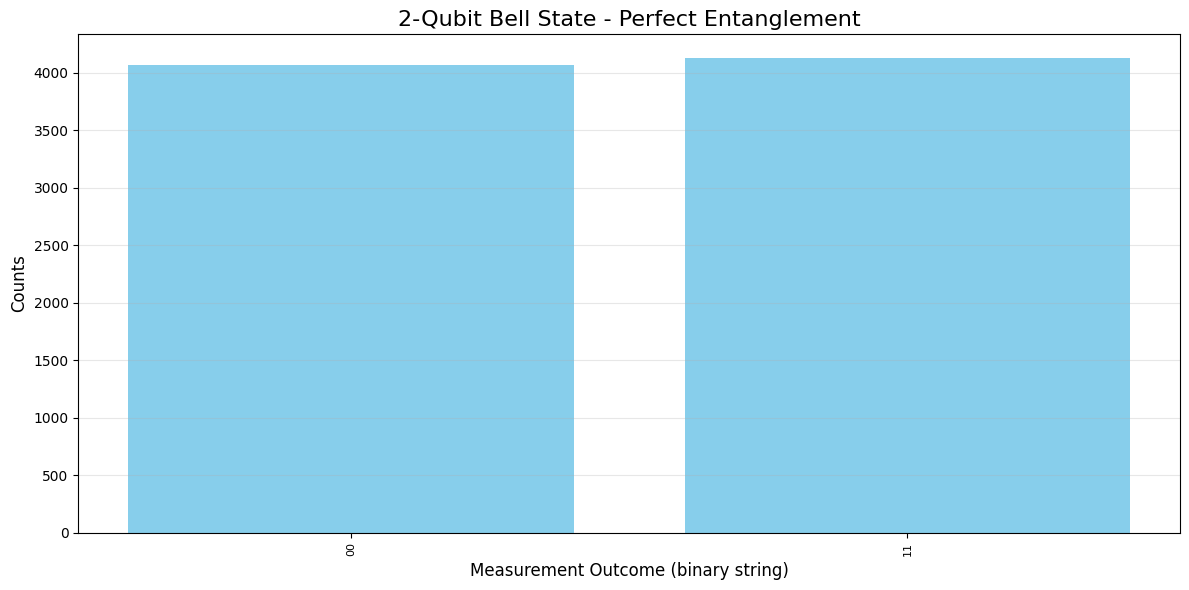

In [30]:
#Start QASM -- text based language. Opens the same on every program.
program = """
OPENQASM 2.0;
"""

program += """
qreg q[1];
"""

program += """
creg c[1];
"""

program += """
h q[0];
"""

program += """
measure q[0] -> c[0];
"""

print(program)

#Data handling and communication protocols -- Import JSON for working with
#JavaScript Object Notation and making HTTP requests to 'Quantum Emulator'
import json
import requests
import matplotlib.pyplot as plt
from collections import Counter

#Suppress warnings (optional, but needed for visual output)
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)  # Disable warnings about insecure requests

da_Vinci_Quantum_Emulator = 'theq-ae31b1'

#Quantum Emulator address
QUOKKA_URL = 'http://{}.quokkacomputing.com/qsim/qasm'.format(da_Vinci_Quantum_Emulator)

SHOTS = 8192                          # Number of measurement shots

# ================================================================

def run_qasm(qasm_code: str, shots: int = SHOTS):
    """Send OpenQASM 2.0 code to the Quokka Puck and return measurement counts."""
    payload = {
        "script": qasm_code.strip(),
        "count": shots
    }
    try:
        response = requests.post(QUOKKA_URL, json=payload, timeout=30)
        response.raise_for_status()
        raw_results = response.json()
        if raw_results and 'result' in raw_results and 'c' in raw_results['result']:
            # Convert list of lists like [[0, 0], [1, 1]] to a list of strings like ["00", "11"]
            measurement_outcomes = ["".join(map(str, res)) for res in raw_results['result']['c']]
            return Counter(measurement_outcomes) # Return a dictionary of outcome -> count
        else:
            print("Unexpected response format from Quokka Puck:", raw_results)
            return {}
    except Exception as e:
        print(f"Error communicating with Quokka Puck: {e}")
        return {}

def plot_results(results: dict, title: str):
    """Plot measurement histogram."""
    if not results:
        print("No results to plot.")
        return

    counts = Counter(results)
    labels = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(12, 6))
    plt.bar(labels, values, color='skyblue')
    plt.title(title, fontsize=16)
    plt.xlabel("Measurement Outcome (binary string)", fontsize=12)
    plt.ylabel("Counts", fontsize=12)
    plt.xticks(rotation=90, fontsize=8)
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # ========================= BELL STATE =========================
print("=== Running 2-Qubit Bell State ===")

bell_qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[2];
creg c[2];

h q[0];          // Create superposition
cx q[0], q[1];   // Entangle the two qubits
measure q[0] -> c[0];
measure q[1] -> c[1];
"""

bell_results = run_qasm(bell_qasm, SHOTS)
print("Bell State Results (top 10):", dict(list(bell_results.items())[:10]))

plot_results(bell_results, "2-Qubit Bell State - Perfect Entanglement")